# ☠️ Causes of Death Worldwide — What's Actually Killing Us?
**Author:** Fatima Zahra Boutkhil
**Dataset:** Our World in Data — Annual Number of Deaths by Cause
**Tools:** Python (Pandas, Matplotlib, Seaborn) + SQL (SQLite)

---

## Introduction

We often hear about wars, disasters, and epidemics dominating the news.
But what does the data actually say about what's killing humanity?

In this project I explore global causes of death across countries and decades
to uncover surprising patterns — what we've solved, what's getting worse,
and how Morocco compares to the rest of the world.

---

## Questions I'll Answer

1. What are the top 5 causes of death globally?
2. How have causes of death changed over time — are we improving?
3. Which cause has increased the most in the last 20 years?
4. Which cause has decreased the most — what did we actually solve?
5. What is the leading killer by region?
6. How does Morocco compare to the global average?

---

In [1]:
# Import libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3


df = pd.read_csv('C:/Users/Fatima zahra/OneDrive/Desktop/csv_files/project2/annual-number-of-deaths-by-cause.csv')


conn = sqlite3.connect('causes_of_death.db')
df.to_sql('causes_of_death', conn, if_exists='replace', index=False)


test = pd.read_sql_query("SELECT COUNT(*) as total FROM causes_of_death", conn)
print(f"📊 Total rows in database: {test['total'][0]}")


print(df.shape)
df.head()

📊 Total rows in database: 8254
(8254, 36)


,Entity,Code,Year,Number of executions (Amnesty International),Deaths - Meningitis - Sex: Both - Age: All Ages (Number),Deaths - Neoplasms - Sex: Both - Age: All Ages (Number),"Deaths - Fire, heat, and hot substances - Sex: Both - Age: All Ages (Number)",Deaths - Malaria - Sex: Both - Age: All Ages (Number),Deaths - Drowning - Sex: Both - Age: All Ages (Number),Deaths - Interpersonal violence - Sex: Both - Age: All Ages (Number),...,Deaths - Protein-energy malnutrition - Sex: Both - Age: All Ages (Number),Terrorism (deaths),Deaths - Cardiovascular diseases - Sex: Both - Age: All Ages (Number),Deaths - Chronic kidney disease - Sex: Both - Age: All Ages (Number),Deaths - Chronic respiratory diseases - Sex: Both - Age: All Ages (Number),Deaths - Cirrhosis and other chronic liver diseases - Sex: Both - Age: All Ages (Number),Deaths - Digestive diseases - Sex: Both - Age: All Ages (Number),Deaths - Acute hepatitis - Sex: Both - Age: All Ages (Number),Deaths - Alzheimer's disease and other dementias - Sex: Both - Age: All Ages (Number),Deaths - Parkinson's disease - Sex: Both - Age: All Ages (Number)
0,Afghanistan,AFG,2007,15,2933.0,15925.0,481.0,393.0,2127.0,3657.0,...,2439.0,1199.0,53962.0,4490.0,7222.0,3346.0,6458.0,3437.0,1402.0,450.0
1,Afghanistan,AFG,2008,17,2731.0,16148.0,462.0,255.0,1973.0,3785.0,...,2231.0,1092.0,54051.0,4534.0,7143.0,3316.0,6408.0,3005.0,1424.0,455.0
2,Afghanistan,AFG,2009,0,2460.0,16383.0,448.0,239.0,1852.0,3874.0,...,1998.0,1065.0,53964.0,4597.0,7045.0,3291.0,6358.0,2663.0,1449.0,460.0
3,Afghanistan,AFG,2011,2,2327.0,17094.0,448.0,390.0,1775.0,4170.0,...,1805.0,1525.0,54347.0,4785.0,6916.0,3318.0,6370.0,2365.0,1508.0,473.0
4,Afghanistan,AFG,2012,14,2254.0,17522.0,445.0,94.0,1716.0,4245.0,...,1667.0,3521.0,54868.0,4846.0,6878.0,3353.0,6398.0,2264.0,1544.0,482.0


In [2]:
df.columns = df.columns.str.replace(r'Deaths - ', '', regex=True)
df.columns = df.columns.str.replace(r' - Sex: Both - Age: All Ages \(Number\)', '', regex=True)

print(df.columns.tolist())

['Entity', 'Code', 'Year', 'Number of executions (Amnesty International)', 'Meningitis', 'Neoplasms', 'Fire, heat, and hot substances', 'Malaria', 'Drowning', 'Interpersonal violence', 'HIV/AIDS', 'Drug use disorders', 'Tuberculosis', 'Road injuries', 'Maternal disorders', 'Lower respiratory infections', 'Neonatal disorders', 'Alcohol use disorders', 'Exposure to forces of nature', 'Diarrheal diseases', 'Environmental heat and cold exposure', 'Nutritional deficiencies', 'Self-harm', 'Conflict and terrorism', 'Diabetes mellitus', 'Poisonings', 'Protein-energy malnutrition', 'Terrorism (deaths)', 'Cardiovascular diseases', 'Chronic kidney disease', 'Chronic respiratory diseases', 'Cirrhosis and other chronic liver diseases', 'Digestive diseases', 'Acute hepatitis', "Alzheimer's disease and other dementias", "Parkinson's disease"]


In [3]:
df.isnull().sum()

Entity                                             0
Code                                            2048
Year                                               0
Number of executions (Amnesty International)    7987
Meningitis                                       244
Neoplasms                                        244
Fire, heat, and hot substances                   244
Malaria                                          244
Drowning                                         244
Interpersonal violence                           244
HIV/AIDS                                         244
Drug use disorders                               244
Tuberculosis                                     244
Road injuries                                    244
Maternal disorders                               244
Lower respiratory infections                     244
Neonatal disorders                               244
Alcohol use disorders                            244
Exposure to forces of nature                  

## Data Cleaning — Handling Missing Values
Before we start analyzing, let's check if our dataset has any missing values 
and decide how to handle them.

In [5]:
# Drop columns that are mostly empty and not useful
df = df.drop(columns=['Number of executions (Amnesty International)', 'Terrorism (deaths)'])

# Fill missing death counts with 0
death_columns = df.columns[3:]
df[death_columns] = df[death_columns].fillna(0)

# Verify no more missing values
print("Remaining missing values:")
print(df.isnull().sum())
print(f"\n✅ Dataset shape after cleaning: {df.shape}")

Remaining missing values:
Entity                                           0
Code                                          2048
Year                                             0
Meningitis                                       0
Neoplasms                                        0
Fire, heat, and hot substances                   0
Malaria                                          0
Drowning                                         0
Interpersonal violence                           0
HIV/AIDS                                         0
Drug use disorders                               0
Tuberculosis                                     0
Road injuries                                    0
Maternal disorders                               0
Lower respiratory infections                     0
Neonatal disorders                               0
Alcohol use disorders                            0
Exposure to forces of nature                     0
Diarrheal diseases                               0
Envir

## Why I filled missing death counts with 0
When a country has no recorded deaths for a cause, the missing value 
most likely means zero cases — not that data is unavailable.
Filling with the average would incorrectly suggest high death counts 
for countries where that disease barely exists.
Columns with over 95% missing data (Executions, Terrorism) were dropped 
as they are not useful for this analysis.

## Question 1 — What are the top 5 causes of death globally?
Most people assume wars or disasters are the biggest killers.
Let's see what the data actually says.

In [6]:
death_cols = df.columns[3:]

df_melted = df.melt(
    id_vars=['Entity', 'Code', 'Year'],
    value_vars=death_cols,
    var_name='Cause',
    value_name='Deaths'
)

top5 = df_melted[df_melted['Entity'] == 'World'] \
    .groupby('Cause')['Deaths'] \
    .sum() \
    .sort_values(ascending=False) \
    .head(5) \
    .reset_index()

print(top5)

                          Cause       Deaths
0       Cardiovascular diseases  447979666.0
1                     Neoplasms  229876132.0
2  Chronic respiratory diseases  104644807.0
3  Lower respiratory infections   83821839.0
4            Neonatal disorders   76899092.0


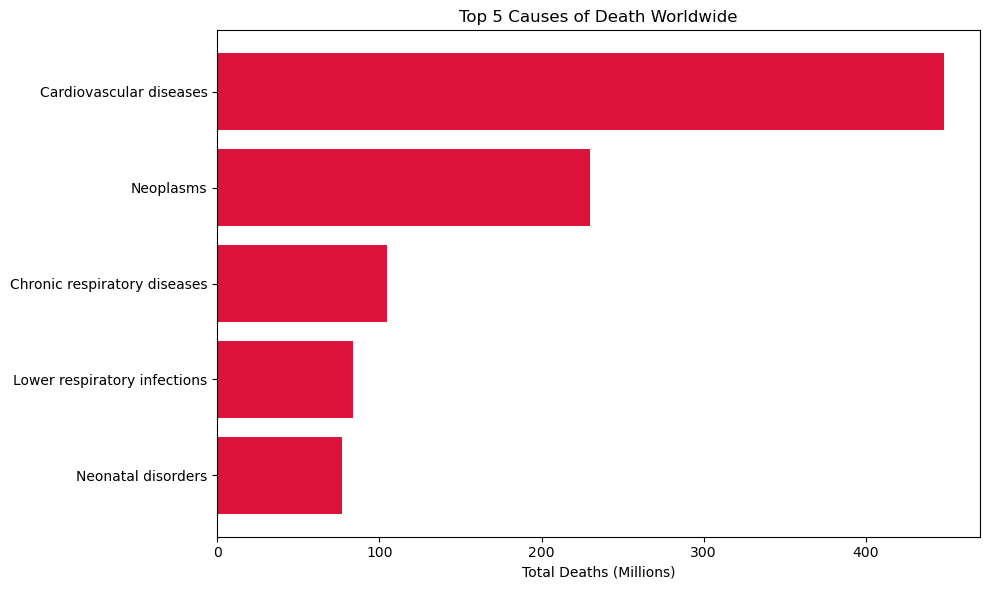

In [7]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.barh(top5['Cause'], top5['Deaths'] / 1_000_000, color='crimson')
plt.xlabel('Total Deaths (Millions)')
plt.title('Top 5 Causes of Death Worldwide')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

### 💡 What did we find?

Cardiovascular diseases are by far the biggest killer globally — 
responsible for nearly 448 million deaths, almost **double** the second 
cause (Cancer/Neoplasms at 229 million).

Wars, terrorism, and natural disasters — which dominate the news — 
don't even make the top 5. The real silent killers are the diseases 
we carry inside us every day.

> *"The most dangerous thing in the room is your own heart."*

## Question 2 — Are we winning? How have global deaths changed over time?
Has humanity actually made progress against disease over the decades?
Let's look at how the top causes have trended over time.

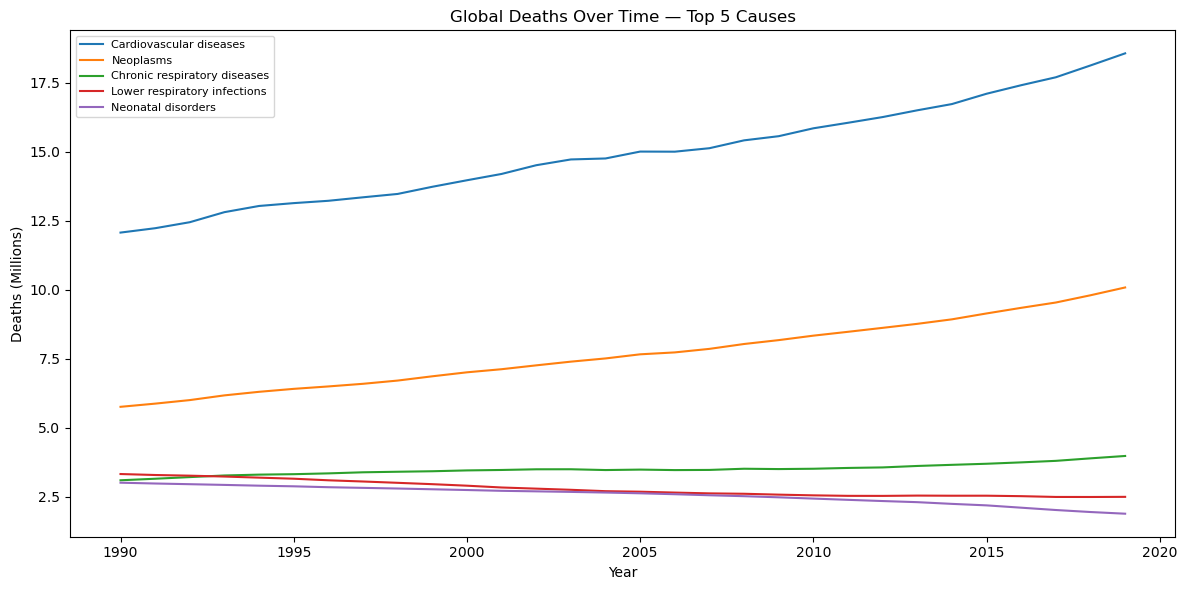

In [8]:
# Filter for World and group by year
top5_causes = top5['Cause'].tolist()

trend = df_melted[
    (df_melted['Entity'] == 'World') & 
    (df_melted['Cause'].isin(top5_causes))
].groupby(['Year', 'Cause'])['Deaths'].sum().reset_index()

# Plot
plt.figure(figsize=(12, 6))
for cause in top5_causes:
    data = trend[trend['Cause'] == cause]
    plt.plot(data['Year'], data['Deaths'] / 1_000_000, label=cause)

plt.title('Global Deaths Over Time — Top 5 Causes')
plt.xlabel('Year')
plt.ylabel('Deaths (Millions)')
plt.legend(loc='upper left', fontsize=8)
plt.tight_layout()
plt.show()

### 💡 What did we find?
Cardiovascular diseases and Cancer deaths are rising — but not because 
we're losing. Global population grew and people are living longer, 
shifting deaths toward age-related diseases.
The real win? Lower respiratory infections and Neonatal disorders 
are declining — meaning fewer babies and young people are dying.
We didn't get less safe. We got older.

## Question 3 — Which cause has increased the most in the last 20 years?
Population growth explains some of the rise — but which disease 
has grown the fastest? The answer might surprise you.

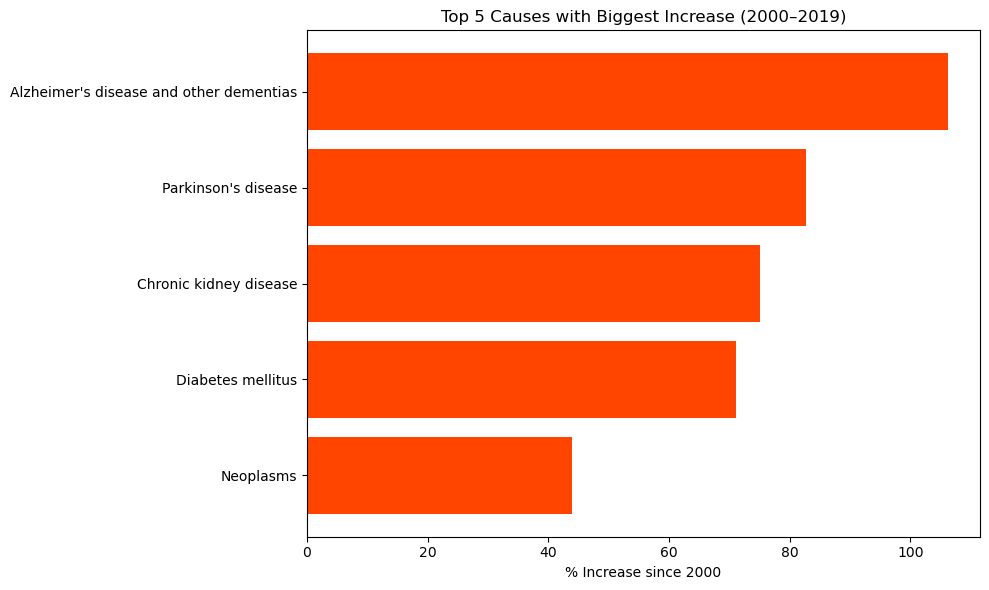

                                     Cause  Pct_Change
0  Alzheimer's disease and other dementias  106.237922
1                      Parkinson's disease   82.682037
2                   Chronic kidney disease   75.041024
3                        Diabetes mellitus   71.032233
4                                Neoplasms   43.884229


In [9]:
# Filter World data for 2000 and 2019
world = df_melted[df_melted['Entity'] == 'World']

deaths_2000 = world[world['Year'] == 2000].groupby('Cause')['Deaths'].sum()
deaths_2019 = world[world['Year'] == 2019].groupby('Cause')['Deaths'].sum()

# Calculate the change
change = ((deaths_2019 - deaths_2000) / deaths_2000 * 100).sort_values(ascending=False)
change_df = change.reset_index()
change_df.columns = ['Cause', 'Pct_Change']

# Top 5 most increased
top5_increase = change_df.head(5)

# Plot
plt.figure(figsize=(10, 6))
plt.barh(top5_increase['Cause'], top5_increase['Pct_Change'], color='orangered')
plt.xlabel('% Increase since 2000')
plt.title('Top 5 Causes with Biggest Increase (2000–2019)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print(top5_increase)

### 💡 What did we find?
Alzheimer's disease leads with over 100% increase since 2000,
followed by Parkinson's and Chronic kidney disease.
Every single disease in this top 5 is age-related.
This confirms what we saw in Question 2 — humanity isn't getting 
sicker, we're getting older. We solved enough diseases to live 
long enough to face entirely new ones.

## Question 4 — What did we actually solve? Which cause decreased the most?
While some diseases are rising, humanity has made remarkable progress 
against others. Let's find the biggest wins.

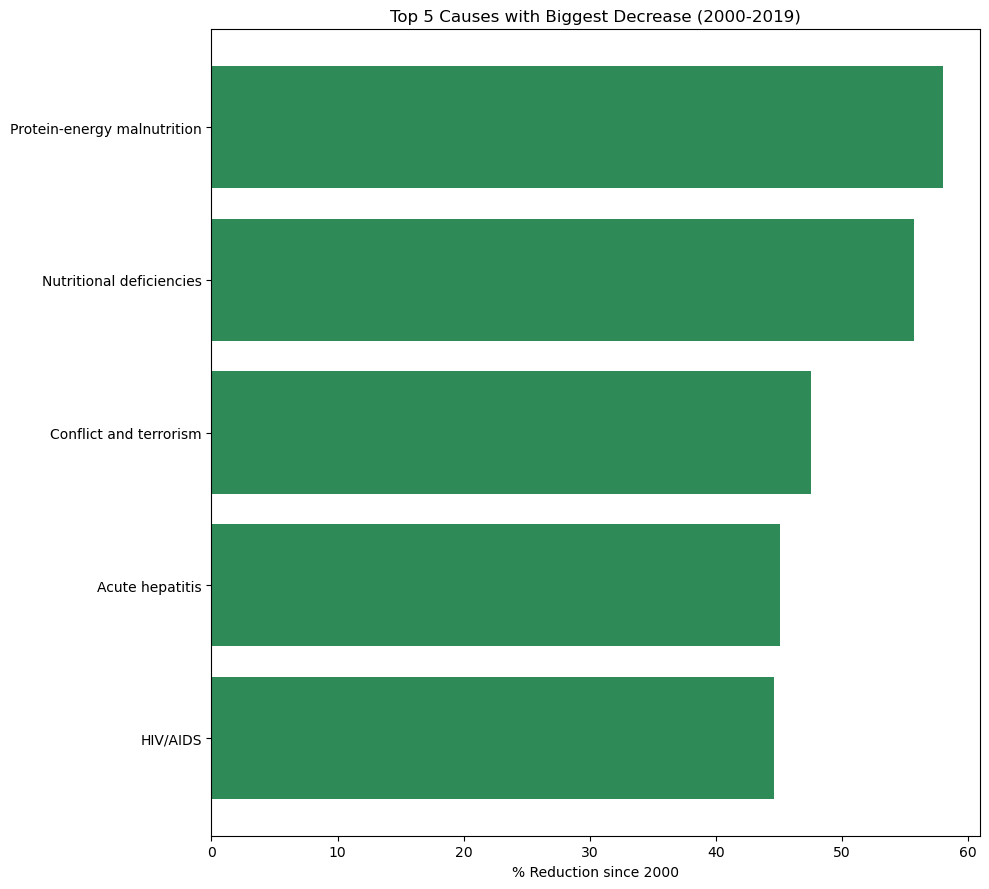

In [14]:
top5_decrease['Improvement'] = top5_decrease['Pct_Change'] * -1

plt.figure(figsize=(10, 9))
plt.barh(top5_decrease['Cause'], top5_decrease['Improvement'], color='seagreen')
plt.xlabel('% Reduction since 2000')
plt.title('Top 5 Causes with Biggest Decrease (2000-2019)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

### 💡 What did we find?
Humanity's biggest wins since 2000:
- Protein-energy malnutrition dropped by ~58% — fewer people starving
- Nutritional deficiencies down ~56% — better food access globally
- Conflict and terrorism deaths reduced by ~48%
- HIV/AIDS down ~45% — thanks to antiretroviral treatments

These aren't small improvements — these are lives saved by the millions
through medicine, aid, and global cooperation.
The world quietly solved problems that never made the headlines.

In [15]:
# Let's see what regions we have
regions = df[df['Code'].isna()]['Entity'].unique()
print(regions)

['Africa' 'African Region' 'African Union' 'America'
 'Andean Latin America' 'Asia' 'Australasia' 'Australasia & Oceania'
 'Bosnia-Herzegovina' 'Caribbean' 'Central America & Caribbean'
 'Central Asia' 'Central Europe'
 'Central Europe, Eastern Europe, and Central Asia'
 'Central Latin America' 'Central sub-Saharan Africa' 'Commonwealth'
 'Commonwealth High Income' 'Commonwealth Low Income'
 'Commonwealth Middle Income' 'East Asia'
 'East Asia & Pacific - World Bank region' 'East Germany (GDR)'
 'East Timor' 'Eastern Europe' 'Eastern Mediterranean Region'
 'Eastern sub-Saharan Africa' 'England' 'Europe'
 'Europe & Central Asia - World Bank region' 'European Region'
 'European Union' 'G20' 'High SDI' 'High-income'
 'High-income Asia Pacific' 'High-income North America' 'High-middle SDI'
 'International' 'Latin America & Caribbean - World Bank region' 'Low SDI'
 'Low-middle SDI' 'Macau' 'Middle East & North Africa' 'Middle SDI'
 'Nordic Region' 'North Africa and Middle East' 'North Ameri

In [16]:
# Pick the most meaningful regions
regions_of_interest = [
    'Sub-Saharan Africa',
    'South Asia',
    'East Asia',
    'North Africa and Middle East',
    'North America',
    'Western Europe',
    'Latin America & Caribbean - World Bank region'
]

# For each region find the leading cause of death
results = []

for region in regions_of_interest:
    region_data = df_melted[
        (df_melted['Entity'] == region) &
        (df_melted['Year'] == 2019)
    ]
    if not region_data.empty:
        top_cause = region_data.groupby('Cause')['Deaths'].sum().idxmax()
        top_deaths = region_data.groupby('Cause')['Deaths'].sum().max()
        results.append({
            'Region': region,
            'Leading Cause': top_cause,
            'Deaths': top_deaths
        })

results_df = pd.DataFrame(results)
print(results_df)

                                          Region            Leading Cause  \
0                                      East Asia  Cardiovascular diseases   
1                   North Africa and Middle East  Cardiovascular diseases   
2                                  North America  Cardiovascular diseases   
3                                 Western Europe  Cardiovascular diseases   
4  Latin America & Caribbean - World Bank region  Cardiovascular diseases   

      Deaths  
0  4727920.0  
1  1296729.0  
2  1040308.0  
3  1433933.0  
4  1099697.0  


In [17]:
# Check what's available for those regions
print(df_melted[df_melted['Entity'] == 'Sub-Saharan Africa']['Year'].unique())
print(df_melted[df_melted['Entity'] == 'South Asia']['Year'].unique())

[1990 1991 1992 1994 1995 1996 1997 1998 1999 2000 2001 2002 2003 2004
 2005 2006 2007 2008 2009 2010 2011 2012 2013 2014 2015 2016 2017]
[1990 1991 1992 1994 1995 1996 1997 1998 1999 2000 2001 2002 2003 2004
 2005 2006 2007 2008 2009 2010 2011 2012 2013 2014 2015 2016 2017]


In [18]:
# Use 2017 as it's available for all regions
regions_of_interest = [
    'Sub-Saharan Africa',
    'South Asia',
    'East Asia',
    'North Africa and Middle East',
    'North America',
    'Western Europe',
    'Latin America & Caribbean - World Bank region'
]

results = []

for region in regions_of_interest:
    region_data = df_melted[
        (df_melted['Entity'] == region) &
        (df_melted['Year'] == 2017)
    ]
    if not region_data.empty:
        top_cause = region_data.groupby('Cause')['Deaths'].sum().idxmax()
        top_deaths = region_data.groupby('Cause')['Deaths'].sum().max()
        results.append({
            'Region': region,
            'Leading Cause': top_cause,
            'Deaths': top_deaths
        })

results_df = pd.DataFrame(results)
print(results_df)

                                          Region            Leading Cause  \
0                             Sub-Saharan Africa          Acute hepatitis   
1                                     South Asia          Acute hepatitis   
2                                      East Asia  Cardiovascular diseases   
3                   North Africa and Middle East  Cardiovascular diseases   
4                                  North America  Cardiovascular diseases   
5                                 Western Europe  Cardiovascular diseases   
6  Latin America & Caribbean - World Bank region  Cardiovascular diseases   

      Deaths  
0        0.0  
1        0.0  
2  4517019.0  
3  1235847.0  
4   974957.0  
5  1363893.0  
6  1045649.0  


In [19]:
# Check Sub-Saharan Africa data for 2017
test = df_melted[
    (df_melted['Entity'] == 'Sub-Saharan Africa') &
    (df_melted['Year'] == 2017)
]
print(test.sort_values('Deaths', ascending=False).head(10))

                    Entity Code  Year  \
6929    Sub-Saharan Africa  NaN  2017   
138993  Sub-Saharan Africa  NaN  2017   
246295  Sub-Saharan Africa  NaN  2017   
238041  Sub-Saharan Africa  NaN  2017   
229787  Sub-Saharan Africa  NaN  2017   
221533  Sub-Saharan Africa  NaN  2017   
213279  Sub-Saharan Africa  NaN  2017   
205025  Sub-Saharan Africa  NaN  2017   
196771  Sub-Saharan Africa  NaN  2017   
188517  Sub-Saharan Africa  NaN  2017   

                                             Cause  Deaths  
6929                                    Meningitis     0.0  
138993        Environmental heat and cold exposure     0.0  
246295     Alzheimer's disease and other dementias     0.0  
238041                             Acute hepatitis     0.0  
229787                          Digestive diseases     0.0  
221533  Cirrhosis and other chronic liver diseases     0.0  
213279                Chronic respiratory diseases     0.0  
205025                      Chronic kidney disease     0.0  

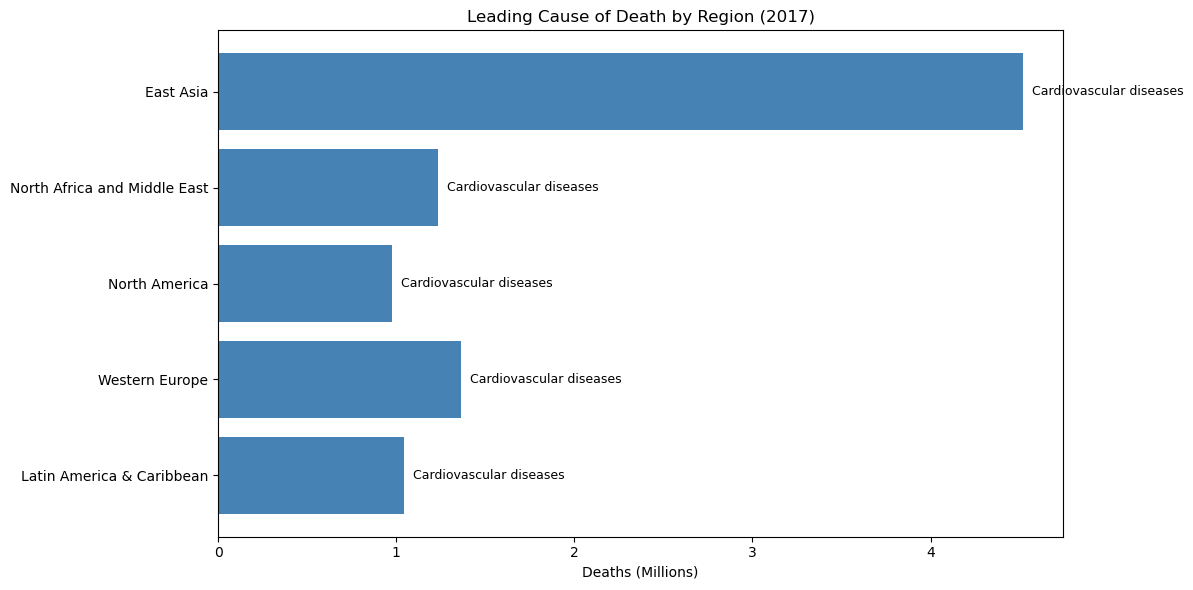

In [20]:
# Filter only regions with real data
results_clean = results_df[results_df['Deaths'] > 0]

# Shorten the long region name for the chart
results_clean = results_clean.copy()
results_clean['Region'] = results_clean['Region'].str.replace(
    'Latin America & Caribbean - World Bank region', 
    'Latin America & Caribbean'
)

# Plot
plt.figure(figsize=(12, 6))
bars = plt.barh(results_clean['Region'], results_clean['Deaths'] / 1_000_000, color='steelblue')
plt.xlabel('Deaths (Millions)')
plt.title('Leading Cause of Death by Region (2017)')
plt.gca().invert_yaxis()

# Add cause labels on the bars
for i, (cause, deaths) in enumerate(zip(results_clean['Leading Cause'], results_clean['Deaths'])):
    plt.text(deaths / 1_000_000 + 0.05, i, cause, va='center', fontsize=9)

plt.tight_layout()
plt.show()

### 💡 What did we find?
No matter where you are in the world — East Asia, North Africa, 
North America, Europe, or Latin America — cardiovascular disease 
is the leading killer everywhere.

Your heart doesn't care about your culture, your language, or your geography.
It's always the heart.

Morocco's region (North Africa and Middle East) is no exception,
with over 1.2 million cardiovascular deaths in 2017 alone.

## Question 6 — How does Morocco compare to the world?
As a Moroccan, I wanted to explore how my country's causes of death 
compare to global trends. Are we following the world pattern 
or is there something unique about Morocco?

In [23]:
# Morocco vs World comparison using Pandas
causes_to_compare = [
    'Cardiovascular diseases',
    'Neoplasms',
    'Diabetes mellitus',
    'Lower respiratory infections',
    'Neonatal disorders',
    'HIV/AIDS',
    'Malaria'
]

# Filter for Morocco and World in 2017
morocco_world = df[
    (df['Entity'].isin(['Morocco', 'World'])) &
    (df['Year'] == 2017)
][['Entity'] + causes_to_compare]

print(morocco_world) 

       Entity  Cardiovascular diseases  Neoplasms  Diabetes mellitus  \
4861  Morocco                 112904.0    26250.0             6138.0   
8013    World               17695752.0  9534619.0          1456169.0   

      Lower respiratory infections  Neonatal disorders  HIV/AIDS   Malaria  
4861                        6432.0              6194.0     600.0       0.0  
8013                     2489649.0           2016024.0  947838.0  629854.0  


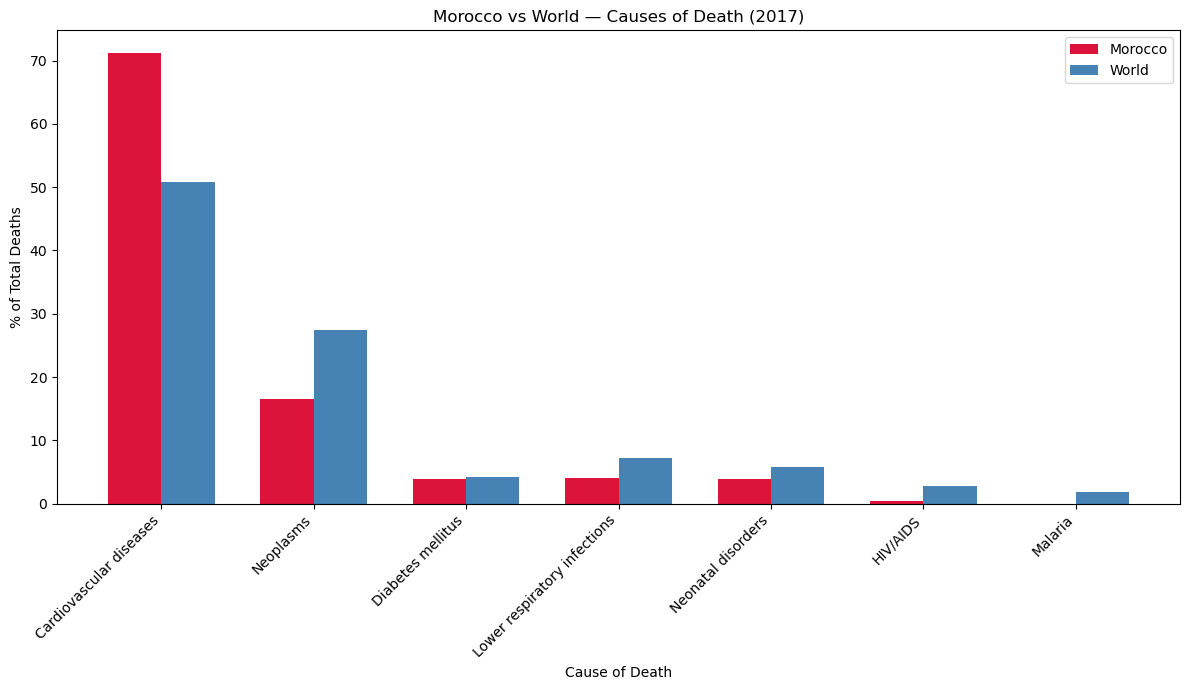

In [24]:
# Convert to percentage of total deaths for fair comparison
morocco_world_pct = morocco_world.copy()
morocco_world_pct = morocco_world_pct.set_index('Entity')
morocco_world_pct = morocco_world_pct.div(morocco_world_pct.sum(axis=1), axis=0) * 100

# Melt for plotting
morocco_world_melted = morocco_world_pct.reset_index().melt(
    id_vars='Entity',
    var_name='Cause',
    value_name='Percentage'
)

# Plot
plt.figure(figsize=(12, 7))
import numpy as np
x = np.arange(len(causes_to_compare))
width = 0.35

morocco_data = morocco_world_melted[morocco_world_melted['Entity'] == 'Morocco']['Percentage'].values
world_data = morocco_world_melted[morocco_world_melted['Entity'] == 'World']['Percentage'].values

plt.bar(x - width/2, morocco_data, width, label='Morocco', color='crimson')
plt.bar(x + width/2, world_data, width, label='World', color='steelblue')

plt.xlabel('Cause of Death')
plt.ylabel('% of Total Deaths')
plt.title('Morocco vs World — Causes of Death (2017)')
plt.xticks(x, causes_to_compare, rotation=45, ha='right')
plt.legend()
plt.tight_layout()
plt.show()

### 💡 What did we find?
Morocco's cardiovascular death rate (~71%) is significantly higher 
than the global average (~51%) — the biggest gap in our comparison.

The good news? Morocco has nearly eliminated HIV/AIDS and Malaria 
as causes of death, well below the world average.

Cancer deaths are also lower than the global average in Morocco.
The heart remains Morocco's biggest health challenge.

## Conclusion — What's Actually Killing Us?

When I started this project, I assumed wars, disasters, and epidemics 
would dominate the data. The reality was completely different.

### Key findings:

1. **Cardiovascular disease is the undisputed #1 killer globally** — 
responsible for nearly 448 million deaths, almost double cancer.

2. **We're not getting less safe — we're getting older.** Rising deaths 
from Alzheimer's, Parkinson's, and Cancer reflect longer lifespans, 
not failure.

3. **Humanity's biggest wins since 2000:** Protein-energy malnutrition 
down 58%, HIV/AIDS down 45%, Nutritional deficiencies down 56%. 
The world quietly solved problems that never made headlines.

4. **It's always the heart.** Every region in the world — from East Asia 
to North America to North Africa — shares the same #1 killer.

5. **Morocco specifically** has a cardiovascular death rate significantly 
above the global average, while having nearly eliminated HIV/AIDS 
and Malaria. The heart is Morocco's biggest health challenge.

### Final thought:
The news covers wars and disasters. The data tells a different story — 
the real battle is silent, happens inside our bodies every day, 
and cardiovascular disease is winning.

---
*Analysis by Fatima Zahra Boutkhil | Data: Our World in Data*